# Case Study 2 — Report 7 (Test 5B)

**CORAL loss weight tuning**

Student: Sanjeev Veeramani (Matr. 100004303)
Supervisor: Prof. Dr. Binh Vu

---

**Objective.** Test 5 (λ_coral=1.0) hurt binary per-trial by 9 pp. Retune with 3 smaller λ values to find whether CORAL can help when properly scaled.

**λ values tested:**
- λ = 0.01  (very weak CORAL — mostly cross-entropy)
- λ = 0.1   (moderate CORAL)
- λ = 0.5   (stronger CORAL, half of Test 5)

**Compare to:** Test 4 (zero-shot, no CORAL) and Test 5 (λ=1.0).

**Setup:** Same val/test split as Test 4/5 (val [1,2,3], test [4-15]).

**Grid:** 3 λ values × 4 configs (2 mappings × 2 protocols) = 12 runs.

**Expected runtime:** ~3-4 hours on L4 GPU.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/case_study_2'
assert os.path.isdir(PROJECT_ROOT)

Mounted at /content/drive


In [2]:
import torch, numpy as np, pandas as pd, time, gc
from pathlib import Path
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, precision_score, recall_score)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Device: NVIDIA L4


## 2. Configuration

In [3]:
CONFIG = {
    'deap_de_perwindow':  'processed/X_deap_DE_zscored.npy',
    'deap_subj_ids':      'processed/deap_subject_ids.npy',
    'deap_val_bin':       'processed/y_deap_valence.npy',
    'deap_val_3c':        'processed/y_deap_3class.npy',

    'seed_de_perwindow':  'processed/X_seed_DE_zscored.npy',
    'seed_subj_ids':      'processed/seed_subject_ids.npy',
    'seed_labels':        'processed/y_seed.npy',
    'seed_de_pertrial':      'processed/X_seed_DE_pertrial.npy',
    'seed_subj_ids_pertrial':'processed/subj_seed_pertrial.npy',
    'seed_labels_pertrial':  'processed/y_seed_pertrial.npy',

    'deap_n_subjects':    32,
    'deap_n_trials':      40,

    'results_dir':  'results/report7_test5b_coral_tuning',

    'lr':            1e-3,
    'weight_decay':  1e-4,
    'mmd_lambda':    0.1,

    'coral_lambdas': [0.01, 0.1, 0.5],   # 3 values to test

    'val_subjects':  [1, 2, 3],
    'test_subjects': list(range(4, 16)),
}

RESULTS_DIR = Path(PROJECT_ROOT) / CONFIG['results_dir']
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'CORAL lambdas to test: {CONFIG["coral_lambdas"]}')

CORAL lambdas to test: [0.01, 0.1, 0.5]


## 3. Load data

In [4]:
root = Path(PROJECT_ROOT)

X_deap_pw  = np.load(root / CONFIG['deap_de_perwindow']).astype(np.float32)
subj_deap  = np.load(root / CONFIG['deap_subj_ids']).astype(np.int64)
y_deap_bin = np.load(root / CONFIG['deap_val_bin']).astype(np.int64)
y_deap_3c  = np.load(root / CONFIG['deap_val_3c']).astype(np.int64)

n_sub_d, n_tr_d = CONFIG['deap_n_subjects'], CONFIG['deap_n_trials']
n_win_d = X_deap_pw.shape[0] // (n_sub_d * n_tr_d)
X_deap_pt = X_deap_pw.reshape(n_sub_d, n_tr_d, n_win_d, -1).mean(axis=2).reshape(-1, X_deap_pw.shape[-1])
y_deap_bin_pt = y_deap_bin.reshape(n_sub_d, n_tr_d, n_win_d)[:, :, 0].reshape(-1)
y_deap_3c_pt  = y_deap_3c.reshape(n_sub_d, n_tr_d, n_win_d)[:, :, 0].reshape(-1)
subj_deap_pt = np.repeat(np.arange(1, n_sub_d + 1), n_tr_d).astype(np.int64)

X_seed_pw    = np.load(root / CONFIG['seed_de_perwindow']).astype(np.float32)
subj_seed_pw = np.load(root / CONFIG['seed_subj_ids']).astype(np.int64)
y_seed_pw    = np.load(root / CONFIG['seed_labels']).astype(np.int64)
X_seed_pt    = np.load(root / CONFIG['seed_de_pertrial']).astype(np.float32)
subj_seed_pt = np.load(root / CONFIG['seed_subj_ids_pertrial']).astype(np.int64)
y_seed_pt    = np.load(root / CONFIG['seed_labels_pertrial']).astype(np.int64)

print(f'DEAP per-window: {X_deap_pw.shape}, per-trial: {X_deap_pt.shape}')
print(f'SEED per-window: {X_seed_pw.shape}, per-trial: {X_seed_pt.shape}')

DEAP per-window: (152320, 160), per-trial: (1280, 160)
SEED per-window: (304785, 160), per-trial: (675, 160)


## 4. Split SEED into val/test

In [5]:
val_subjs = set(CONFIG['val_subjects'])
test_subjs = set(CONFIG['test_subjects'])

def split(X, y, subj):
    vm = np.isin(subj, list(val_subjs))
    tm = np.isin(subj, list(test_subjs))
    return {'val': (X[vm], y[vm], subj[vm]), 'test': (X[tm], y[tm], subj[tm])}

SEED_SPLITS = {
    'per_trial':  split(X_seed_pt, y_seed_pt, subj_seed_pt),
    'per_window': split(X_seed_pw, y_seed_pw, subj_seed_pw),
}

def map_binary(X, y, s):
    m = (y == 0) | (y == 2)
    return X[m], (y[m] == 2).astype(np.int64), s[m]
def map_3class(X, y, s):
    return X, y.astype(np.int64), s

DATA = {}
for protocol in ['per_trial', 'per_window']:
    for role in ['val', 'test']:
        X, y, s = SEED_SPLITS[protocol][role]
        for mapping, fn in [('binary', map_binary), ('3class', map_3class)]:
            Xm, ym, sm = fn(X, y, s)
            DATA[(mapping, protocol, role)] = (Xm, ym, sm)
            print(f'{mapping} × {protocol} × {role}: {Xm.shape}')

binary × per_trial × val: (90, 160)
3class × per_trial × val: (135, 160)
binary × per_trial × test: (360, 160)
3class × per_trial × test: (540, 160)
binary × per_window × val: (41130, 160)
3class × per_window × val: (60957, 160)
binary × per_window × test: (164520, 160)
3class × per_window × test: (243828, 160)


## 5. Model + CORAL loss

In [6]:
EMBED_DIM = 128

class AttentionPool(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(in_dim, hidden), nn.Tanh(),
                                   nn.Linear(hidden, 1))
    def forward(self, x):
        w = self.score(x).squeeze(-1)
        w = torch.softmax(w, dim=1).unsqueeze(-1)
        return (x * w).sum(dim=1)

class CNNLSTMAttentionExtractor(nn.Module):
    def __init__(self, n_bands=5, embed=EMBED_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_bands, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True,
                            dropout=0.3, bidirectional=False)
        self.attn = AttentionPool(128, hidden=64)
        self.fc = nn.Sequential(nn.Linear(128, embed), nn.ReLU(), nn.Dropout(0.3))
    def forward(self, x):
        b = x.size(0)
        x = x.view(b, 32, 5).transpose(1, 2)
        x = self.conv(x).transpose(1, 2)
        h, _ = self.lstm(x)
        return self.fc(self.attn(h))

class EmotionModel(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.extractor = CNNLSTMAttentionExtractor()
        self.head = nn.Sequential(
            nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes))
    def forward(self, x, return_features=False):
        feat = self.extractor(x)
        logits = self.head(feat)
        return (logits, feat) if return_features else logits

def linear_mmd_by_subject(features, subject_ids):
    unique = torch.unique(subject_ids)
    if len(unique) < 2:
        return torch.tensor(0.0, device=features.device)
    means = [features[subject_ids == s].mean(dim=0)
             for s in unique if (subject_ids == s).sum() > 0]
    means = torch.stack(means)
    diffs = means.unsqueeze(0) - means.unsqueeze(1)
    sq = (diffs * diffs).sum(dim=-1)
    n = len(unique)
    return sq.sum() / max(n * (n - 1), 1)

def coral_loss(source_feat, target_feat):
    d = source_feat.size(1)
    src_c = source_feat - source_feat.mean(0, keepdim=True)
    tgt_c = target_feat - target_feat.mean(0, keepdim=True)
    ns = max(source_feat.size(0), 2)
    nt = max(target_feat.size(0), 2)
    cov_s = (src_c.t() @ src_c) / (ns - 1)
    cov_t = (tgt_c.t() @ tgt_c) / (nt - 1)
    return ((cov_s - cov_t) ** 2).sum() / (4 * d * d)

## 6. Training with CORAL (given λ)

In [7]:
def train_with_coral(X_train_np, y_train_np, subj_train_np,
                     X_seed_unlabeled_np, X_val_np, y_val_np,
                     X_test_np, y_test_np,
                     n_classes, epochs, batch_size, lr, wd,
                     mmd_lambda, coral_lambda):
    X_tr = torch.from_numpy(X_train_np).to(DEVICE)
    y_tr = torch.from_numpy(y_train_np).long().to(DEVICE)
    s_tr = torch.from_numpy(subj_train_np).long().to(DEVICE)
    X_seed_pool = torch.from_numpy(X_seed_unlabeled_np).to(DEVICE)
    X_val = torch.from_numpy(X_val_np).to(DEVICE)
    X_te  = torch.from_numpy(X_test_np).to(DEVICE)

    unique_s = torch.unique(s_tr)
    remap = torch.zeros(int(unique_s.max()) + 1, dtype=torch.long, device=DEVICE)
    remap[unique_s] = torch.arange(unique_s.size(0), device=DEVICE)
    s_tr_remap = remap[s_tr]

    model = EmotionModel(n_classes).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    counts = np.bincount(y_train_np, minlength=n_classes)
    w = 1.0 / (counts + 1e-10); w = w / w.sum() * n_classes
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))

    best_val_bal, best_state, best_epoch = -1.0, None, 0
    n = X_tr.size(0)
    n_seed = X_seed_pool.size(0)

    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            if idx.size(0) < 2: continue
            xb_src, yb, sb = X_tr[idx], y_tr[idx], s_tr_remap[idx]
            seed_idx = torch.randint(0, n_seed, (idx.size(0),), device=DEVICE)
            xb_tgt = X_seed_pool[seed_idx]

            opt.zero_grad()
            src_logits, src_feat = model(xb_src, return_features=True)
            _,           tgt_feat = model(xb_tgt, return_features=True)

            ce   = loss_fn(src_logits, yb)
            mmd  = linear_mmd_by_subject(src_feat, sb)
            coral = coral_loss(src_feat, tgt_feat)
            loss = ce + mmd_lambda * mmd + coral_lambda * coral

            loss.backward(); opt.step()
        sched.step()

        model.eval()
        with torch.no_grad():
            preds_val = []
            for i in range(0, X_val.size(0), batch_size*2):
                preds_val.append(model(X_val[i:i+batch_size*2]).argmax(dim=1))
            y_pred_val = torch.cat(preds_val).cpu().numpy()
        val_bal = balanced_accuracy_score(y_val_np, y_pred_val)

        if val_bal > best_val_bal:
            best_val_bal = val_bal
            best_epoch = ep
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        preds_test = []
        for i in range(0, X_te.size(0), batch_size*2):
            preds_test.append(model(X_te[i:i+batch_size*2]).argmax(dim=1))
        y_pred_test = torch.cat(preds_test).cpu().numpy()

    test_bal = balanced_accuracy_score(y_test_np, y_pred_test)
    return y_pred_test, test_bal, best_val_bal, best_epoch

## 7. Main loop — 3 λ values × 4 configs = 12 runs

In [8]:
def get_deap_train_set(mapping, protocol):
    if protocol == 'per_trial':
        X = X_deap_pt; subj = subj_deap_pt
        y = y_deap_bin_pt if mapping == 'binary' else y_deap_3c_pt
    else:
        X = X_deap_pw; subj = subj_deap
        y = y_deap_bin if mapping == 'binary' else y_deap_3c
    return X.astype(np.float32), y.astype(np.int64), subj.astype(np.int64)

def get_seed_pool(protocol):
    return X_seed_pt.astype(np.float32) if protocol == 'per_trial' else X_seed_pw.astype(np.float32)

ALL_RESULTS = {}
for coral_lambda in CONFIG['coral_lambdas']:
    print(f'\n{"#"*60}\n# λ_coral = {coral_lambda}\n{"#"*60}')
    for mapping in ['binary', '3class']:
        for protocol in ['per_trial', 'per_window']:
            key = (coral_lambda, mapping, protocol)
            print(f'\n[λ={coral_lambda}] {mapping} × {protocol}')

            X_train, y_train, subj_train = get_deap_train_set(mapping, protocol)
            X_seed_pool = get_seed_pool(protocol)
            X_val, y_val, _   = DATA[(mapping, protocol, 'val')]
            X_test, y_test, _ = DATA[(mapping, protocol, 'test')]

            n_classes = 3 if mapping == '3class' else 2
            batch = 512 if protocol == 'per_window' else 128
            epochs = 20 if protocol == 'per_window' else 40

            t0 = time.time()
            y_pred, test_bal, val_bal, best_ep = train_with_coral(
                X_train, y_train, subj_train, X_seed_pool,
                X_val, y_val, X_test, y_test,
                n_classes, epochs, batch,
                CONFIG['lr'], CONFIG['weight_decay'],
                CONFIG['mmd_lambda'], coral_lambda)
            elapsed = time.time() - t0

            print(f'  epoch {best_ep+1} | val {100*val_bal:.2f}% | test {100*test_bal:.2f}% | time {elapsed:.1f}s')

            ALL_RESULTS[key] = {
                'y_true': y_test, 'y_pred': y_pred,
                'test_bal': test_bal, 'val_bal': val_bal, 'best_epoch': best_ep,
            }

            del X_train, y_train, subj_train, X_seed_pool
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()


############################################################
# λ_coral = 0.01
############################################################

[λ=0.01] binary × per_trial
  epoch 8 | val 58.89% | test 60.56% | time 23.8s

[λ=0.01] binary × per_window
  epoch 4 | val 59.38% | test 66.83% | time 161.9s

[λ=0.01] 3class × per_trial
  epoch 8 | val 39.26% | test 41.30% | time 12.1s

[λ=0.01] 3class × per_window
  epoch 3 | val 40.38% | test 42.90% | time 159.5s

############################################################
# λ_coral = 0.1
############################################################

[λ=0.1] binary × per_trial
  epoch 5 | val 60.00% | test 66.11% | time 8.6s

[λ=0.1] binary × per_window
  epoch 2 | val 58.01% | test 68.59% | time 154.0s

[λ=0.1] 3class × per_trial
  epoch 9 | val 42.96% | test 36.67% | time 8.8s

[λ=0.1] 3class × per_window
  epoch 2 | val 43.72% | test 47.01% | time 156.3s

############################################################
# λ_coral = 0.5
#########

## 8. Aggregate + compare to Test 4 (zero-shot) and Test 5 (λ=1.0)

In [9]:
# Test 4 baseline (from earlier run)
TEST4 = {
    ('binary',  'per_trial'):  68.89,
    ('binary',  'per_window'): 65.11,
    ('3class',  'per_trial'):  40.56,
    ('3class',  'per_window'): 43.98,
}
# Test 5 (λ=1.0) results
TEST5 = {
    ('binary',  'per_trial'):  60.00,
    ('binary',  'per_window'): 67.58,
    ('3class',  'per_trial'):  42.78,
    ('3class',  'per_window'): 42.63,
}

rows = []
for (lam, mapping, protocol), r in ALL_RESULTS.items():
    rows.append({
        'lambda': lam,
        'mapping': mapping,
        'protocol': protocol,
        'val_bal':  100 * r['val_bal'],
        'test_bal': 100 * r['test_bal'],
        'best_epoch': r['best_epoch'] + 1,
    })
DF = pd.DataFrame(rows)
DF.to_csv(RESULTS_DIR / 'test5b_all.csv', index=False)
print('=== All λ values ===')
print(DF.to_string(index=False))

# Comparison table
compare = []
for mapping in ['binary', '3class']:
    for protocol in ['per_trial', 'per_window']:
        row = {
            'config':             f'{mapping}_{protocol}',
            'Test 4 (no CORAL)':  TEST4[(mapping, protocol)],
            'Test 5 λ=1.0':       TEST5[(mapping, protocol)],
        }
        for lam in CONFIG['coral_lambdas']:
            r = ALL_RESULTS.get((lam, mapping, protocol))
            row[f'Test 5B λ={lam}'] = 100 * r['test_bal'] if r else None
        # Find best across all CORAL variants
        coral_scores = [row[f'Test 5B λ={lam}'] for lam in CONFIG['coral_lambdas']] + [row['Test 5 λ=1.0']]
        row['CORAL best'] = max(x for x in coral_scores if x is not None)
        row['CORAL best beats zero-shot?'] = row['CORAL best'] > row['Test 4 (no CORAL)']
        compare.append(row)

DF_C = pd.DataFrame(compare)
DF_C.to_csv(RESULTS_DIR / 'test5b_comparison.csv', index=False)
print('\n=== Comparison ===')
print(DF_C.to_string(index=False))

=== All λ values ===
 lambda mapping   protocol   val_bal  test_bal  best_epoch
   0.01  binary  per_trial 58.888889 60.555556           8
   0.01  binary per_window 59.382294 66.830862           4
   0.01  3class  per_trial 39.259259 41.296296           8
   0.01  3class per_window 40.382762 42.900384           3
   0.10  binary  per_trial 60.000000 66.111111           5
   0.10  binary per_window 58.007575 68.586510           2
   0.10  3class  per_trial 42.962963 36.666667           9
   0.10  3class per_window 43.715385 47.006207           2
   0.50  binary  per_trial 58.888889 64.722222           4
   0.50  binary per_window 59.183581 64.878769           5
   0.50  3class  per_trial 41.481481 45.000000           4
   0.50  3class per_window 41.455959 45.771278           1

=== Comparison ===
           config  Test 4 (no CORAL)  Test 5 λ=1.0  Test 5B λ=0.01  Test 5B λ=0.1  Test 5B λ=0.5  CORAL best  CORAL best beats zero-shot?
 binary_per_trial              68.89         60.00    

## 9. Plot — λ sweep results

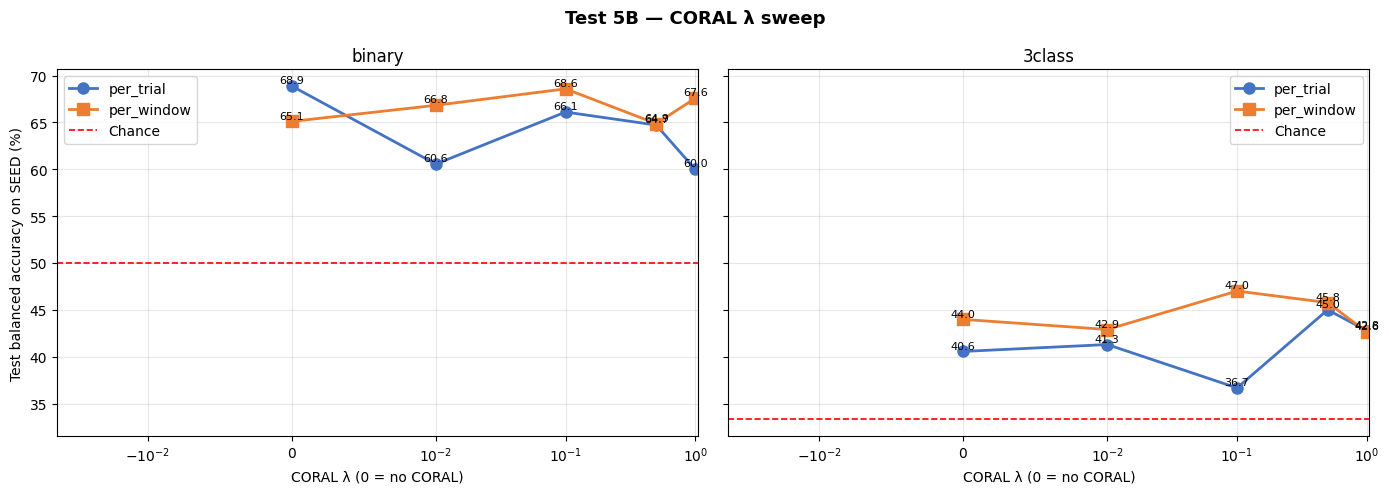

In [10]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})
PLOTS_DIR = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, mapping in zip(axes, ['binary', '3class']):
    for protocol, marker, color in [('per_trial', 'o', '#4472C4'), ('per_window', 's', '#ED7D31')]:
        xs = [0] + list(CONFIG['coral_lambdas']) + [1.0]   # 0 = Test 4 zero-shot
        ys = [TEST4[(mapping, protocol)]]
        for lam in CONFIG['coral_lambdas']:
            r = ALL_RESULTS.get((lam, mapping, protocol))
            ys.append(100 * r['test_bal'] if r else None)
        ys.append(TEST5[(mapping, protocol)])
        ax.plot(xs, ys, marker=marker, color=color, label=protocol, linewidth=2, markersize=8)
        for x, y in zip(xs, ys):
            if y is not None:
                ax.text(x, y + 0.3, f'{y:.1f}', ha='center', fontsize=8)
    ch = 50.0 if mapping == 'binary' else 33.3
    ax.axhline(ch, color='red', linestyle='--', linewidth=1.2, label='Chance')
    ax.set_xlabel('CORAL λ (0 = no CORAL)')
    ax.set_xscale('symlog', linthresh=0.01)
    ax.set_title(mapping)
    ax.legend()
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Test balanced accuracy on SEED (%)')
plt.suptitle('Test 5B — CORAL λ sweep', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'test5b_lambda_sweep.png', dpi=140, bbox_inches='tight')
plt.show()

## 10. Interpretation

**What each λ means:**
- λ = 0 (Test 4): no CORAL — pure zero-shot
- λ = 0.01: very weak alignment — barely different from zero-shot
- λ = 0.1: moderate alignment
- λ = 0.5: strong alignment (like MMD's weight)
- λ = 1.0 (Test 5): very strong — dominates cross-entropy in some configs

**What to look for in the plot:**
- **U-shape (dip in middle):** CORAL hurts at all values — abandon CORAL
- **Peak at small λ:** CORAL helps slightly when kept small
- **Monotone decrease with λ:** CORAL uniformly hurts — abandon
- **Monotone increase with λ:** CORAL might help even more at λ > 1 — retry higher

**Decision:**
- If any λ value beats Test 4 by >2 pp on binary: use that λ, retry Test 5B with more values
- If all λ values are within ±1 pp of Test 4: CORAL doesn't help, revert to Test 4 numbers
- If all λ values worse than Test 4: CORAL doesn't fit this problem